11 datasets chargés.
             Dataset Dimension  nb
0  Composite IoT/UAV         C   5
1  Composite IoT/UAV         M  13
2  Composite IoT/UAV         P  13
3        UAVIDS-2025         C   3
4        UAVIDS-2025         M  10
5        UAVIDS-2025         P   6
M (10) : ['TxPackets', 'RxPackets', 'LostPackets', 'TxBytes', 'RxBytes', 'TxPacketRate/s', 'RxPacketRate/s', 'TxByteRate/s', 'RxByteRate/s', 'PacketDropRate']
C (3) : ['Protocol', 'SrcPort', 'DstPort']
P (6) : ['FlowDuration/s', 'MeanDelay/s', 'MeanJitter/s', 'Throughput/Kbps', 'MeanPacketSize', 'AverageHopCount']
Classes : <ArrowStringArray>
[    'Sybil Attack', 'Blackhole Attack',  'Wormhole Attack',
  'Flooding Attack',   'Normal Traffic']
Length: 5, dtype: str
  Sybil Attack              → M=10  C=3  P=6
  Blackhole Attack          → M=10  C=3  P=6
  Wormhole Attack           → M=10  C=3  P=6
  Flooding Attack           → M=10  C=3  P=6
  Normal Traffic            → M=10  C=3  P=6
Test : Sybil Attack ↔ Blackhole Attack
 

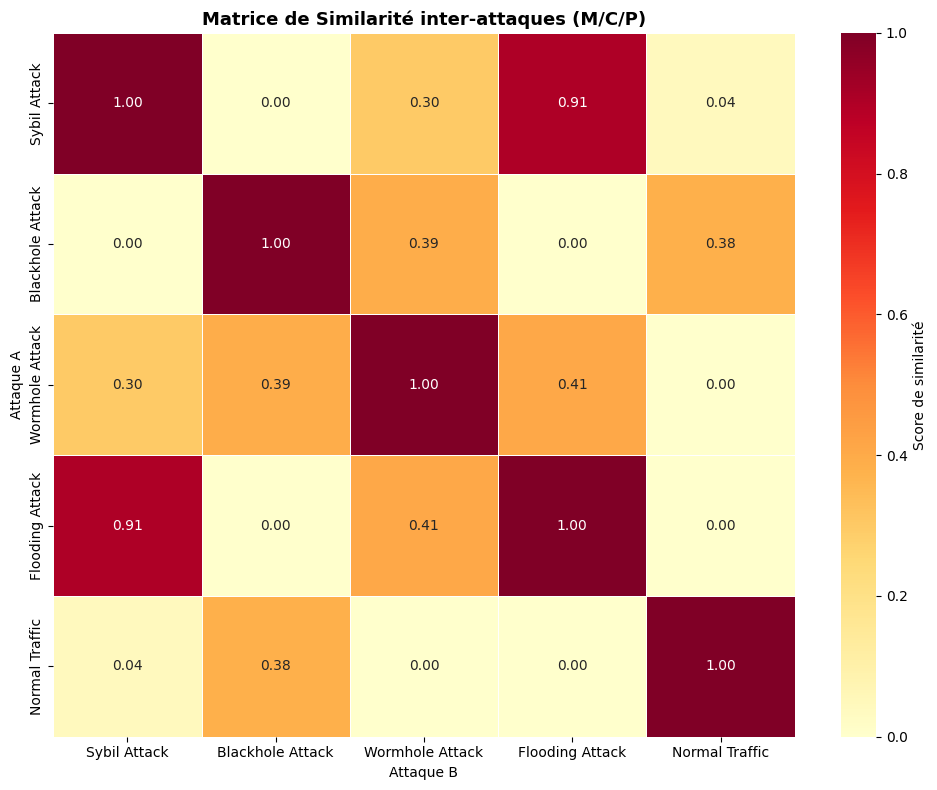

matrice_similarite_globale.png


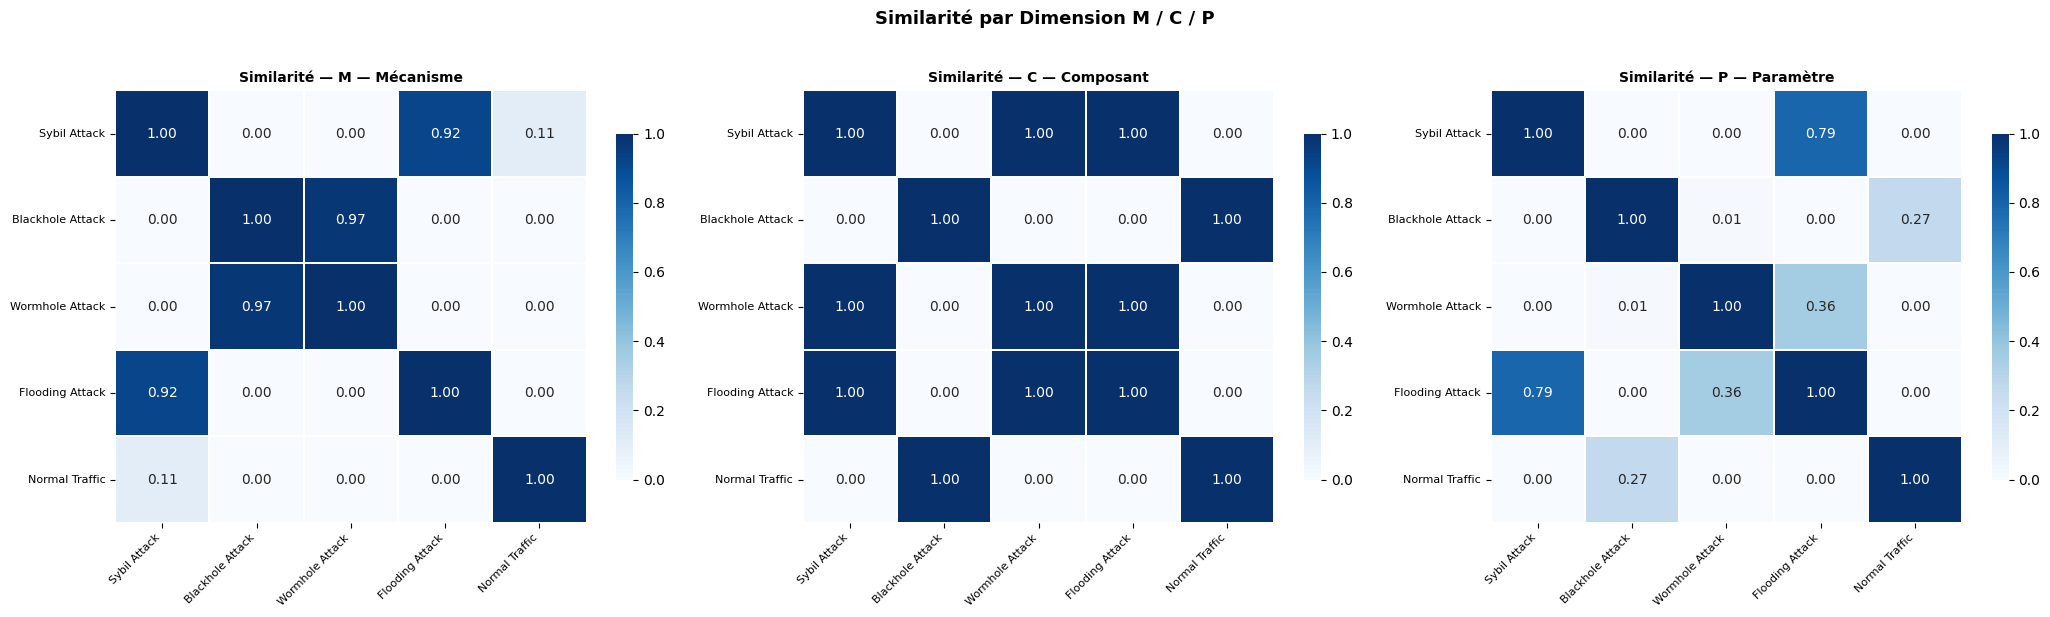

matrice_similarite_MCP.png
Top 10 paires les plus similaires :
                             Paire  Sim_Totale    Sim_M  Sim_C    Sim_P Dimension_dominante
    Flooding Attack ↔ Sybil Attack    0.905652 0.919611    1.0 0.792691           Composant
 Flooding Attack ↔ Wormhole Attack    0.406939 0.000000    1.0 0.356463           Composant
Blackhole Attack ↔ Wormhole Attack    0.391727 0.968891    0.0 0.013901           Mécanisme
 Blackhole Attack ↔ Normal Traffic    0.379547 0.000000    1.0 0.265157           Composant
    Sybil Attack ↔ Wormhole Attack    0.300000 0.000000    1.0 0.000000           Composant
     Normal Traffic ↔ Sybil Attack    0.042419 0.106047    0.0 0.000000           Mécanisme
   Blackhole Attack ↔ Sybil Attack    0.000000 0.000000    0.0 0.000000           Mécanisme
Blackhole Attack ↔ Flooding Attack    0.000000 0.000000    0.0 0.000000           Mécanisme
  Flooding Attack ↔ Normal Traffic    0.000000 0.000000    0.0 0.000000           Mécanisme
  Normal Traffic 

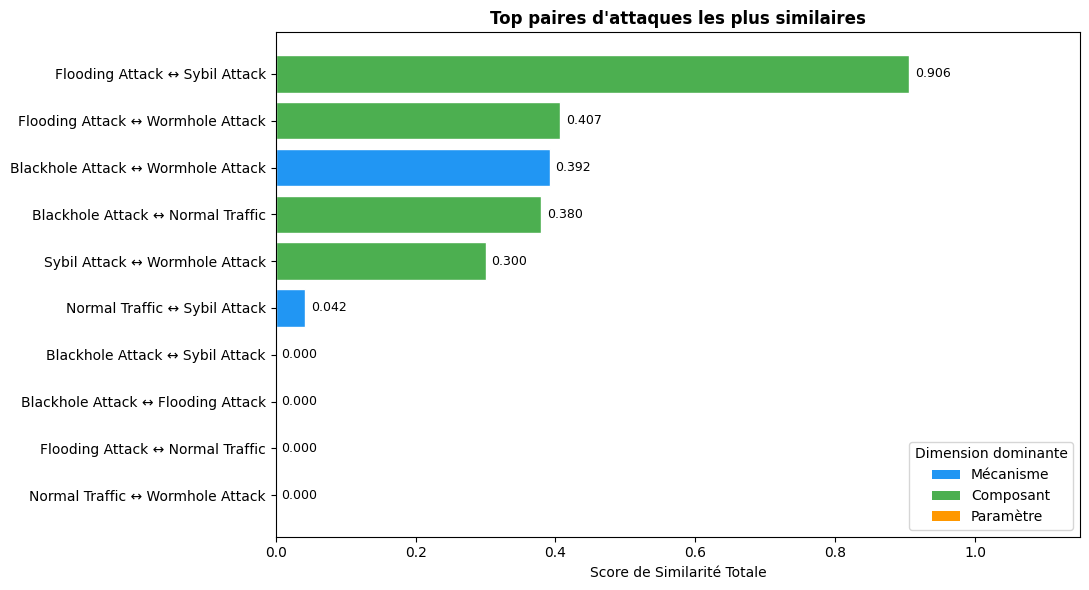

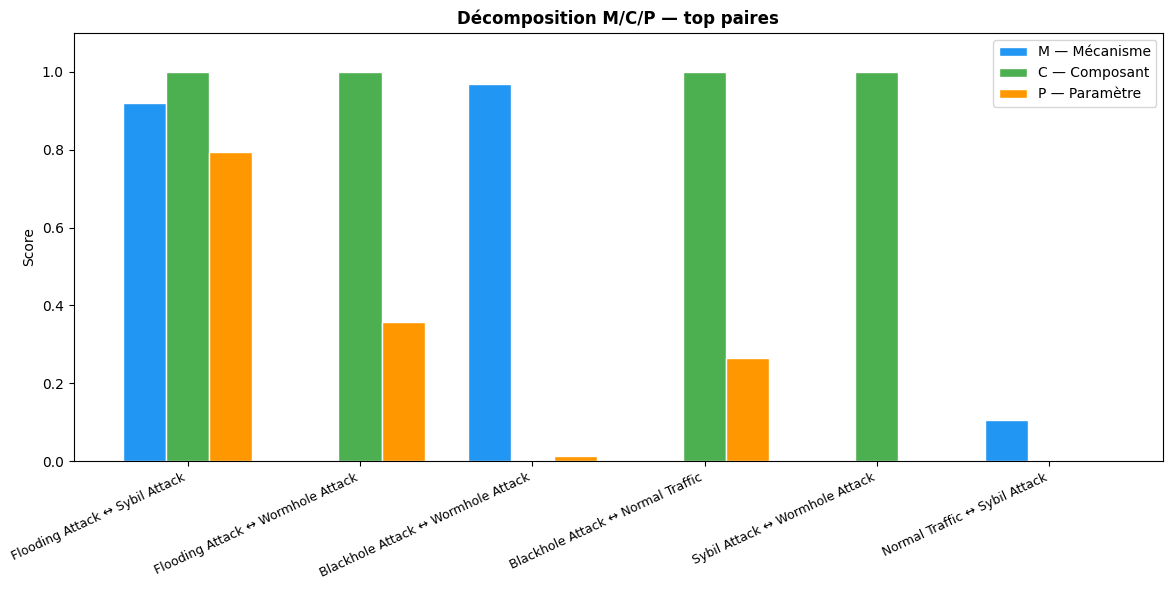

top_paires_similarite.png
decomposition_MCP_top_paires.png
Fichiers Power BI exportés :
similarite_paires.csv
similarite_matrice.csv
similarite_resume.csv
distribution_classes.csv


In [ ]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

FINAL_PATH   = r"C:\Drone_Attack_Similarity_Project\DATASET\Final"
TABLES_PATH  = r"C:\Drone_Attack_Similarity_Project\Rapport\tables"
FIGURES_PATH = r"C:\Drone_Attack_Similarity_Project\Rapport\figures"
os.makedirs(TABLES_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

LABEL_COL   = "label"

W1, W2, W3  = 0.4, 0.3, 0.3

datasets = {}
for fname in os.listdir(FINAL_PATH):
    if fname.endswith("_final.csv"):
        name = fname.replace("_final.csv", "").replace("_", "-")
        datasets[name] = pd.read_csv(FINAL_PATH + "\\" + fname)

df_mapping = pd.read_csv(TABLES_PATH + "\\mapping_MCP_complet.csv")
print(f"{len(datasets)} datasets chargés.")
print(df_mapping.groupby(["Dataset", "Dimension"]).size().reset_index(name="nb"))

def get_features(df_map, dataset, dim):
    return df_map[
        (df_map["Dataset"] == dataset) &
        (df_map["Dimension"] == dim)
    ]["Feature"].tolist()

df_u  = datasets["UAVIDS-2025"]
avail = df_u.columns.tolist()

feat_M = [f for f in get_features(df_mapping, "UAVIDS-2025", "M") if f in avail]
feat_C = [f for f in get_features(df_mapping, "UAVIDS-2025", "C") if f in avail]
feat_P = [f for f in get_features(df_mapping, "UAVIDS-2025", "P") if f in avail]

print(f"M ({len(feat_M)}) : {feat_M}")
print(f"C ({len(feat_C)}) : {feat_C}")
print(f"P ({len(feat_P)}) : {feat_P}")

classes = df_u[LABEL_COL].unique()
print("Classes :", classes)

profils = {}
for cls in classes:
    df_cls = df_u[df_u[LABEL_COL] == cls]
    profils[cls] = {
        "M": df_cls[feat_M].mean().values if feat_M else np.array([]),
        "C": df_cls[feat_C].mean().values if feat_C else np.array([]),
        "P": df_cls[feat_P].mean().values if feat_P else np.array([]),
    }
    print(f"  {cls:<25} → M={len(profils[cls]['M'])}  C={len(profils[cls]['C'])}  P={len(profils[cls]['P'])}")


def cosine_sim(v1, v2):
    if len(v1) == 0 or len(v2) == 0:
        return 0.0
    return float(np.clip(
        cosine_similarity(v1.reshape(1, -1), v2.reshape(1, -1))[0][0], 0, 1
    ))

def similarity(pi, pj, w1=W1, w2=W2, w3=W3):
    sm = cosine_sim(pi["M"], pj["M"])
    sc = cosine_sim(pi["C"], pj["C"])
    sp = cosine_sim(pi["P"], pj["P"])
    return round(w1*sm + w2*sc + w3*sp, 6), round(sm, 6), round(sc, 6), round(sp, 6)

# Test rapide
cls0, cls1 = list(profils.keys())[0], list(profils.keys())[1]
tot, m, c, p = similarity(profils[cls0], profils[cls1])
print(f"Test : {cls0} ↔ {cls1}")
print(f"  Total={tot}  M={m}  C={c}  P={p}")


classes_list = list(profils.keys())
n = len(classes_list)

mat_tot = np.zeros((n, n))
mat_M   = np.zeros((n, n))
mat_C   = np.zeros((n, n))
mat_P   = np.zeros((n, n))
rows    = []

for i, ci in enumerate(classes_list):
    for j, cj in enumerate(classes_list):
        tot, m, c, p = similarity(profils[ci], profils[cj])
        mat_tot[i, j] = tot
        mat_M[i, j]   = m
        mat_C[i, j]   = c
        mat_P[i, j]   = p
        rows.append({
            "Attaque_A"  : ci,
            "Attaque_B"  : cj,
            "Sim_Totale" : tot,
            "Sim_M"      : m,
            "Sim_C"      : c,
            "Sim_P"      : p,
            "Paire"      : f"{ci} ↔ {cj}",
            "Meme_classe": ci == cj,
        })

df_matrix = pd.DataFrame(mat_tot, index=classes_list, columns=classes_list)
df_detail = pd.DataFrame(rows)

print("Matrice de similarité :")
print(df_matrix.round(3).to_string())


fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_matrix,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Score de similarité"},
)
ax.set_title("Matrice de Similarité inter-attaques (M/C/P)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Attaque B")
ax.set_ylabel("Attaque A")
plt.tight_layout()
plt.savefig(FIGURES_PATH + "\\matrice_similarite_globale.png", dpi=150)
plt.show()
print("matrice_similarite_globale.png")

dims = {
    "M — Mécanisme": mat_M,
    "C — Composant": mat_C,
    "P — Paramètre": mat_P,
}
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (title, mat) in zip(axes, dims.items()):
    df_dim = pd.DataFrame(mat, index=classes_list, columns=classes_list)
    sns.heatmap(df_dim, annot=True, fmt=".2f", cmap="Blues",
                vmin=0, vmax=1, ax=ax, linewidths=0.3,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f"Similarité — {title}", fontsize=10, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle("Similarité par Dimension M / C / P",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "\\matrice_similarite_MCP.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("matrice_similarite_MCP.png")

df_pairs = df_detail[
    ~df_detail["Meme_classe"] &
    (df_detail["Attaque_A"] < df_detail["Attaque_B"])
].sort_values("Sim_Totale", ascending=False).reset_index(drop=True)

df_pairs["Dimension_dominante"] = (
    df_pairs[["Sim_M", "Sim_C", "Sim_P"]]
    .idxmax(axis=1)
    .map({"Sim_M": "Mécanisme", "Sim_C": "Composant", "Sim_P": "Paramètre"})
)

print("Top 10 paires les plus similaires :")
print(df_pairs.head(10)[
    ["Paire", "Sim_Totale", "Sim_M", "Sim_C", "Sim_P", "Dimension_dominante"]
].to_string(index=False))


COLOR_M, COLOR_C, COLOR_P = "#2196F3", "#4CAF50", "#FF9800"
couleurs = {"Mécanisme": COLOR_M, "Composant": COLOR_C, "Paramètre": COLOR_P}
top  = df_pairs.head(min(10, len(df_pairs)))
top6 = df_pairs.head(min(6,  len(df_pairs)))

# Barplot horizontal
colors = [couleurs.get(d, "#607D8B") for d in top["Dimension_dominante"]]
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top["Paire"], top["Sim_Totale"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Score de Similarité Totale")
ax.set_title("Top paires d'attaques les plus similaires", fontweight="bold")
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(facecolor=c, label=d) for d, c in couleurs.items()],
    title="Dimension dominante", loc="lower right"
)
plt.tight_layout()
plt.savefig(FIGURES_PATH + "\\top_paires_similarite.png", dpi=150)
plt.show()

# Décomposition M/C/P
x = np.arange(len(top6))
w = 0.25
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.bar(x - w, top6["Sim_M"], w, label="M — Mécanisme", color=COLOR_M, edgecolor="white")
ax2.bar(x,     top6["Sim_C"], w, label="C — Composant",  color=COLOR_C, edgecolor="white")
ax2.bar(x + w, top6["Sim_P"], w, label="P — Paramètre",  color=COLOR_P, edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(top6["Paire"], rotation=25, ha="right", fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Score")
ax2.set_title("Décomposition M/C/P — top paires", fontweight="bold")
ax2.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH + "\\decomposition_MCP_top_paires.png", dpi=150)
plt.show()
print("top_paires_similarite.png")
print("decomposition_MCP_top_paires.png")


# Format long (sans diagonale)
df_off = df_detail[~df_detail["Meme_classe"]].copy()
df_off.to_csv(TABLES_PATH + "\\similarite_paires.csv", index=False)

# Format carré N×N
df_matrix.to_csv(TABLES_PATH + "\\similarite_matrice.csv")

# Résumé dédupliqué
df_pairs.to_csv(TABLES_PATH + "\\similarite_resume.csv", index=False)

# Distribution des classes
dist = df_u[LABEL_COL].value_counts().reset_index()
dist.columns = ["Attaque", "Nb_Echantillons"]
dist.to_csv(TABLES_PATH + "\\distribution_classes.csv", index=False)

print("Fichiers Power BI exportés :")
for f in ["similarite_paires.csv", "similarite_matrice.csv",
        "similarite_resume.csv", "distribution_classes.csv"]:
    print(f"{f}")


